# Fréchet mean と Fréchet regression の可視化

この notebook は次の順に可視化します。

1. 実数直線上では Fréchet mean が通常の平均になること
2. 円周上では geodesic distance により平均位置が決まること
3. Fréchet mean が一意でない場合があること
4. 1 次元 Wasserstein 空間では quantile function を平均すること
5. Fréchet regression が、各 predictor 値で重み付き Fréchet mean を繰り返し計算していること

必要な package は `numpy`, `scipy`, `matplotlib`, `Pillow` です。

## 0. 準備

標本 Fréchet function と sample Fréchet mean は

\[\widehat F(\omega)=\frac1n\sum_{i=1}^n d^2(Y_i,\omega),\qquad \widehat\omega_\oplus=\arg\min_{\omega\in\Omega}\widehat F(\omega)\]

で定義されます。

In [ ]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.animation import FuncAnimation, PillowWriter

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def circle_geodesic_distance(a, b):
    """Geodesic distance on S^1, with angles represented in radians."""
    difference = np.abs(a - b)
    return np.minimum(difference, 2.0 * np.pi - difference)

def pava_increasing(values):
    """L2 projection of a vector onto the cone of nondecreasing sequences."""
    values = np.asarray(values, dtype=float)
    levels, weights, starts, ends = [], [], [], []

    for index, value in enumerate(values):
        levels.append(float(value))
        weights.append(1.0)
        starts.append(index)
        ends.append(index)

        while len(levels) >= 2 and levels[-2] > levels[-1]:
            merged_weight = weights[-2] + weights[-1]
            merged_level = (
                weights[-2] * levels[-2] + weights[-1] * levels[-1]
            ) / merged_weight

            levels[-2] = merged_level
            weights[-2] = merged_weight
            ends[-2] = ends[-1]

            levels.pop()
            weights.pop()
            starts.pop()
            ends.pop()

    projected = np.empty_like(values)
    for level, start, end in zip(levels, starts, ends):
        projected[start : end + 1] = level
    return projected

print(f"Figures and animations will be saved in: {OUTPUT_DIR}")


Figures and animations will be saved in: /mnt/data/frechet_visualization_outputs


## 1. 実数直線上の Fréchet mean

距離を通常の Euclidean distance とすると、Fréchet function は二次関数になり、その minimizer は arithmetic mean と一致します。

Arithmetic mean: 0.160
Grid minimizer of the Fréchet function: 0.155


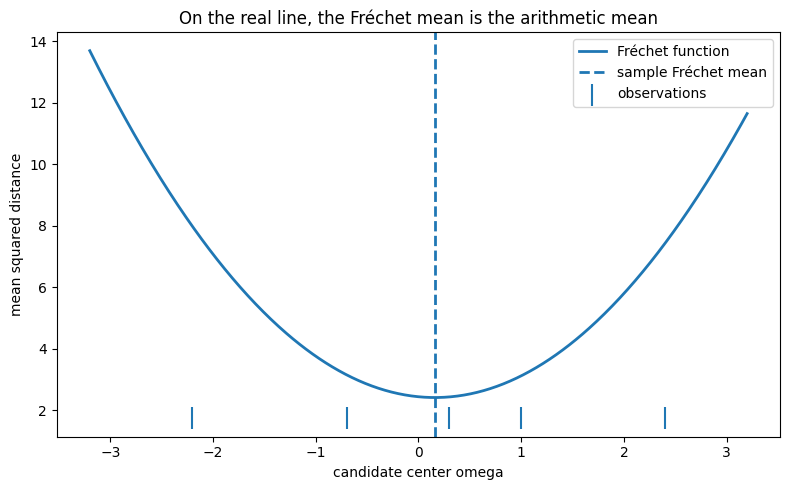

In [2]:

# Sample Fréchet function on R:
# F(omega) = n^{-1} sum_i |Y_i - omega|^2

y_sample = np.array([-2.2, -0.7, 0.3, 1.0, 2.4])
omega_grid = np.linspace(-3.2, 3.2, 600)
frechet_function = np.mean(
    (y_sample[:, None] - omega_grid[None, :]) ** 2,
    axis=0,
)
ordinary_mean = y_sample.mean()
grid_minimizer = omega_grid[np.argmin(frechet_function)]

print(f"Arithmetic mean: {ordinary_mean:.3f}")
print(f"Grid minimizer of the Fréchet function: {grid_minimizer:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(omega_grid, frechet_function, linewidth=2, label="Fréchet function")
plt.axvline(ordinary_mean, linestyle="--", linewidth=2, label="sample Fréchet mean")
rug_height = frechet_function.min() - 0.06 * np.ptp(frechet_function)
plt.scatter(
    y_sample,
    np.full_like(y_sample, rug_height),
    marker="|",
    s=250,
    label="observations",
)
plt.xlabel("candidate center omega")
plt.ylabel("mean squared distance")
plt.title("On the real line, the Fréchet mean is the arithmetic mean")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_euclidean_frechet_function.png", dpi=180)
plt.show()


## 2. 円周上の Fréchet mean

角度の数値を直接平均するのではなく、円周上の geodesic distance を最小化します。0° と 360° の境界は座標表示上の人工的な境界です。

Intrinsic Fréchet mean: 1.44 degrees
Naive arithmetic mean of degree labels: 145.40 degrees


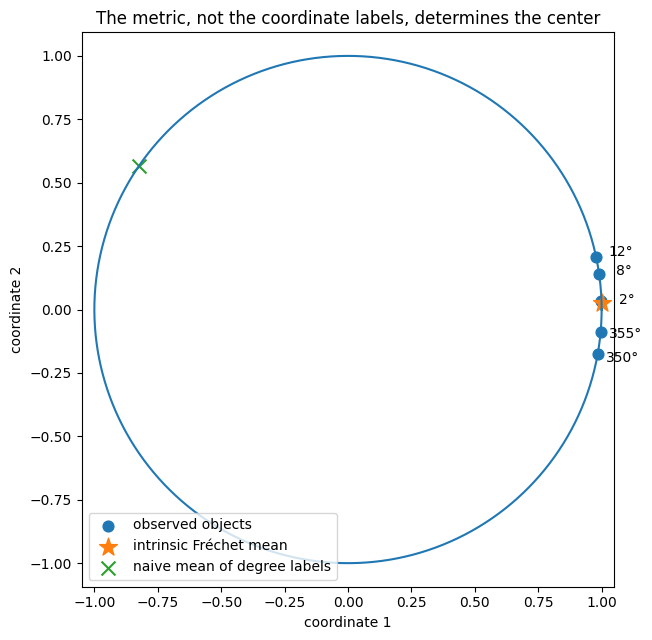

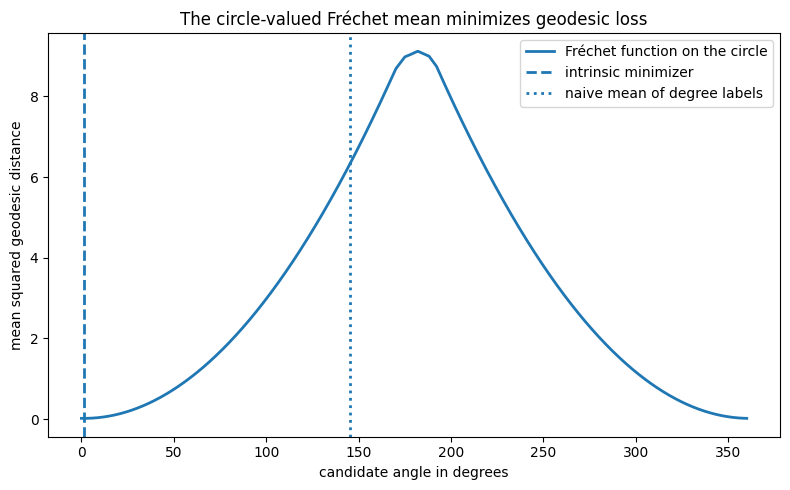

In [3]:

# Angles straddle the artificial 0/360-degree coordinate boundary.
angles_deg = np.array([350.0, 355.0, 2.0, 8.0, 12.0])
angles = np.deg2rad(angles_deg)

candidate_angles = np.linspace(0.0, 2.0 * np.pi, 4001)
circle_frechet_function = np.array([
    np.mean(circle_geodesic_distance(angles, candidate) ** 2)
    for candidate in candidate_angles
])
circle_mean = candidate_angles[np.argmin(circle_frechet_function)]
naive_degree_mean = np.deg2rad(angles_deg.mean())

print(f"Intrinsic Fréchet mean: {np.rad2deg(circle_mean):.2f} degrees")
print(f"Naive arithmetic mean of degree labels: {angles_deg.mean():.2f} degrees")

theta = np.linspace(0.0, 2.0 * np.pi, 600)
plt.figure(figsize=(6.5, 6.5))
plt.plot(np.cos(theta), np.sin(theta), linewidth=1.5)
plt.scatter(
    np.cos(angles),
    np.sin(angles),
    s=60,
    label="observed objects",
)
plt.scatter(
    [np.cos(circle_mean)],
    [np.sin(circle_mean)],
    marker="*",
    s=180,
    label="intrinsic Fréchet mean",
)
plt.scatter(
    [np.cos(naive_degree_mean)],
    [np.sin(naive_degree_mean)],
    marker="x",
    s=100,
    label="naive mean of degree labels",
)
for angle, degree in zip(angles, angles_deg):
    plt.text(
        1.10 * np.cos(angle),
        1.10 * np.sin(angle),
        f"{degree:.0f}°",
        ha="center",
        va="center",
    )
plt.axis("equal")
plt.xlabel("coordinate 1")
plt.ylabel("coordinate 2")
plt.title("The metric, not the coordinate labels, determines the center")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_circle_frechet_mean.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    np.rad2deg(candidate_angles),
    circle_frechet_function,
    linewidth=2,
    label="Fréchet function on the circle",
)
plt.axvline(
    np.rad2deg(circle_mean),
    linestyle="--",
    linewidth=2,
    label="intrinsic minimizer",
)
plt.axvline(
    angles_deg.mean(),
    linestyle=":",
    linewidth=2,
    label="naive mean of degree labels",
)
plt.xlabel("candidate angle in degrees")
plt.ylabel("mean squared geodesic distance")
plt.title("The circle-valued Fréchet mean minimizes geodesic loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_circle_frechet_function.png", dpi=180)
plt.show()


### 一意性が失われる例

二つの観測が antipodal である場合、Fréchet function は二つの同じ深さの minimum を持ちます。

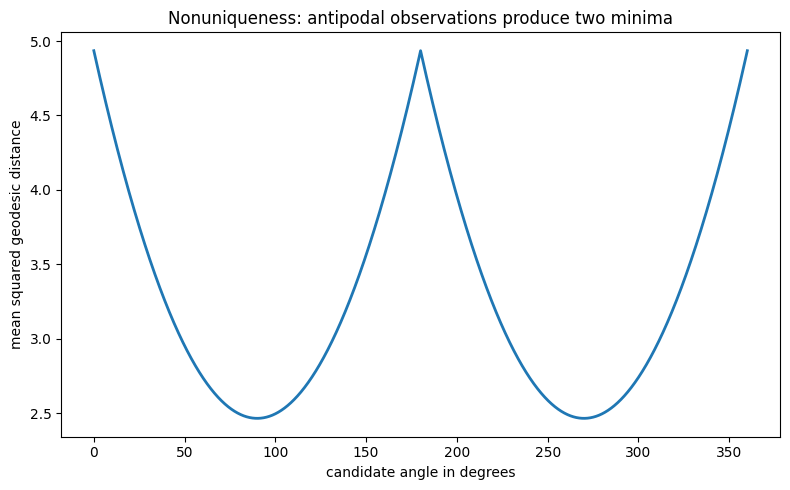

In [4]:

# Optional example: two antipodal observations have two intrinsic Fréchet means.
antipodal = np.array([0.0, np.pi])
antipodal_function = np.array([
    np.mean(circle_geodesic_distance(antipodal, candidate) ** 2)
    for candidate in candidate_angles
])

plt.figure(figsize=(8, 5))
plt.plot(
    np.rad2deg(candidate_angles),
    antipodal_function,
    linewidth=2,
)
plt.xlabel("candidate angle in degrees")
plt.ylabel("mean squared geodesic distance")
plt.title("Nonuniqueness: antipodal observations produce two minima")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_circle_nonunique_mean.png", dpi=180)
plt.show()


## 3. 確率分布の Wasserstein Fréchet mean

実数上の確率分布に 2-Wasserstein distance を入れると、Fréchet mean の quantile function は各 quantile function の平均です。これは density の pointwise average とは異なります。

W2 Fréchet mean of these normal distributions: N(0.00, 0.95^2)


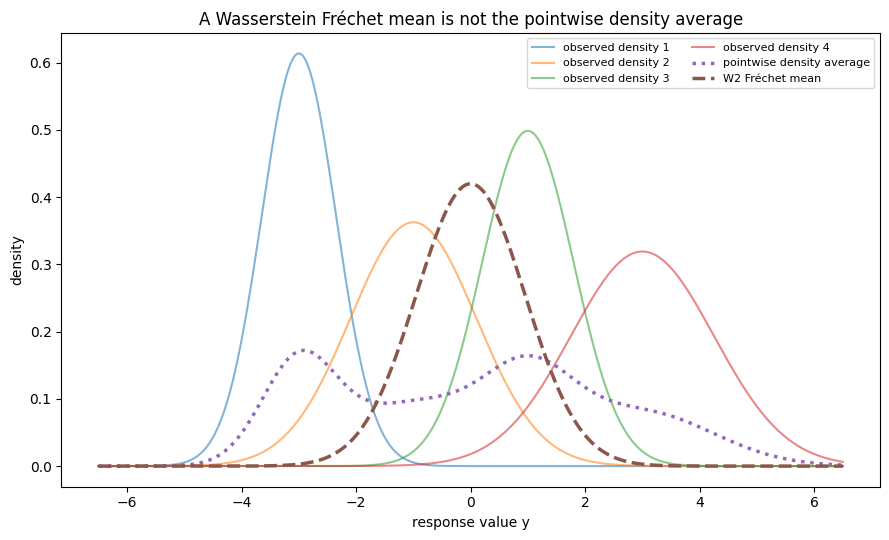

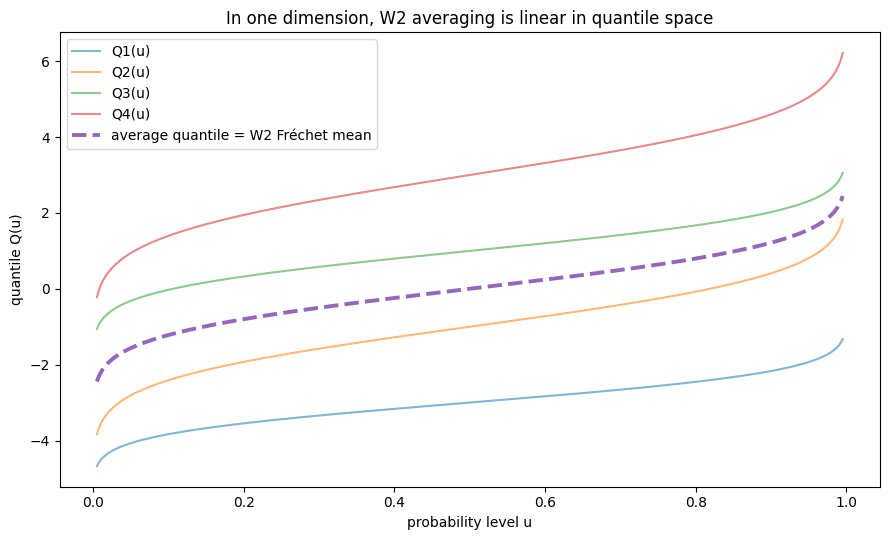

In [5]:

# Four distribution-valued observations.
locations = np.array([-3.0, -1.0, 1.0, 3.0])
scales = np.array([0.65, 1.10, 0.80, 1.25])

# For one-dimensional W2 geometry:
# Q_bar(u) = n^{-1} sum_i Q_i(u).
u = np.linspace(0.005, 0.995, 500)
z = norm.ppf(u)
quantiles = np.array([
    location + scale * z
    for location, scale in zip(locations, scales)
])
mean_quantile = quantiles.mean(axis=0)

barycenter_location = locations.mean()
barycenter_scale = scales.mean()

print(
    "W2 Fréchet mean of these normal distributions: "
    f"N({barycenter_location:.2f}, {barycenter_scale:.2f}^2)"
)

response_grid = np.linspace(-6.5, 6.5, 900)
densities = np.array([
    norm.pdf(response_grid, loc=location, scale=scale)
    for location, scale in zip(locations, scales)
])
pointwise_density_average = densities.mean(axis=0)
barycenter_density = norm.pdf(
    response_grid,
    loc=barycenter_location,
    scale=barycenter_scale,
)

plt.figure(figsize=(9, 5.5))
for index, density in enumerate(densities, start=1):
    plt.plot(
        response_grid,
        density,
        alpha=0.55,
        label=f"observed density {index}",
    )
plt.plot(
    response_grid,
    pointwise_density_average,
    linestyle=":",
    linewidth=2.5,
    label="pointwise density average",
)
plt.plot(
    response_grid,
    barycenter_density,
    linestyle="--",
    linewidth=2.5,
    label="W2 Fréchet mean",
)
plt.xlabel("response value y")
plt.ylabel("density")
plt.title("A Wasserstein Fréchet mean is not the pointwise density average")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_wasserstein_density_mean.png", dpi=180)
plt.show()

plt.figure(figsize=(9, 5.5))
for index, quantile in enumerate(quantiles, start=1):
    plt.plot(u, quantile, alpha=0.55, label=f"Q{index}(u)")
plt.plot(
    u,
    mean_quantile,
    linestyle="--",
    linewidth=2.8,
    label="average quantile = W2 Fréchet mean",
)
plt.xlabel("probability level u")
plt.ylabel("quantile Q(u)")
plt.title("In one dimension, W2 averaging is linear in quantile space")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_wasserstein_quantile_mean.png", dpi=180)
plt.show()


## 4. Distribution-valued Fréchet regression

global Fréchet regression は、target predictor 値 `x` ごとに

\[\widehat m_\oplus(x)=\arg\min_{\omega\in\Omega}\frac1n\sum_{i=1}^n s_i(x)d^2(Y_i,\omega)\]

を計算します。したがって、通常の Fréchet mean を`x`-dependent weights で繰り返す操作と理解できます。

In [6]:

# Distribution-valued regression data:
# each Y_i is a normal distribution represented by (mu_i, sigma_i)
# or equivalently by its quantile function.

rng = np.random.default_rng(2026)
n = 45
X = rng.uniform(-1.0, 1.0, size=n)

mu_observed = 0.4 + 2.0 * X + rng.normal(0.0, 0.35, size=n)
sigma_observed = 1.15 + 0.30 * X + rng.normal(0.0, 0.10, size=n)
sigma_observed = np.maximum(sigma_observed, 0.35)

x_bar = X.mean()
var_x = np.mean((X - x_bar) ** 2)

def global_weight_factors(x):
    """Paper's scalar-predictor global weight factors s_i(x)."""
    return 1.0 + (X - x_bar) * (x - x_bar) / var_x

def fitted_normal_object(x):
    """
    For normal location-scale responses under W2,
    the weighted Fréchet minimizer has weighted location and scale.
    """
    weight_factors = global_weight_factors(x)
    weights = weight_factors / n
    fitted_location = weights @ mu_observed
    fitted_scale = weights @ sigma_observed
    return weight_factors, weights, fitted_location, fitted_scale

def fitted_quantile_object(x):
    """Direct quantile-space implementation, including monotonicity projection."""
    weight_factors, weights, _, _ = fitted_normal_object(x)
    observed_quantiles = (
        mu_observed[:, None]
        + sigma_observed[:, None] * z[None, :]
    )
    raw_quantile = weights @ observed_quantiles
    projected_quantile = pava_increasing(raw_quantile)
    return weight_factors, projected_quantile

print(f"Average of the empirical weight factors is 1 at every target x.")
for target in (-0.8, 0.0, 0.8):
    factors = global_weight_factors(target)
    print(
        f"x={target: .1f}: mean(s_i)={factors.mean():.6f}, "
        f"negative factors={np.sum(factors < 0)}"
    )


Average of the empirical weight factors is 1 at every target x.
x=-0.8: mean(s_i)=1.000000, negative factors=13
x= 0.0: mean(s_i)=1.000000, negative factors=0
x= 0.8: mean(s_i)=1.000000, negative factors=15


### 4.1 predictor 値により weight が変わる

global weight は局所 kernel weight ではなく、負になることがあります。一方で `mean(s_i(x)) = 1` が成り立ちます。

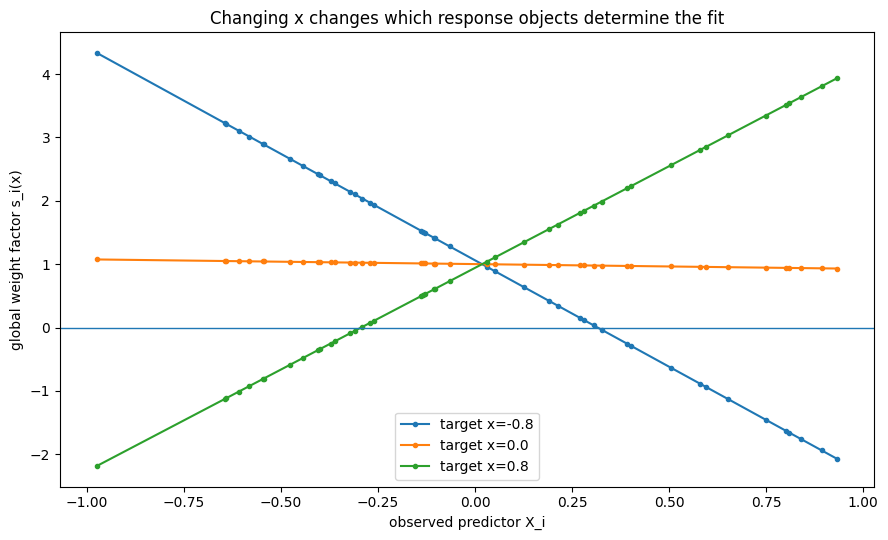

In [7]:

targets = [-0.8, 0.0, 0.8]
order = np.argsort(X)

plt.figure(figsize=(9, 5.5))
for target in targets:
    factors = global_weight_factors(target)
    plt.plot(
        X[order],
        factors[order],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=f"target x={target}",
    )
plt.axhline(0.0, linewidth=1)
plt.xlabel("observed predictor X_i")
plt.ylabel("global weight factor s_i(x)")
plt.title("Changing x changes which response objects determine the fit")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_global_frechet_weights.png", dpi=180)
plt.show()


### 4.2 weighted Fréchet objective の minimizer

normal location-scale family では、Wasserstein geometry を`(mu, sigma)` 平面上に描けます。等高線の最小点が fitted object です。

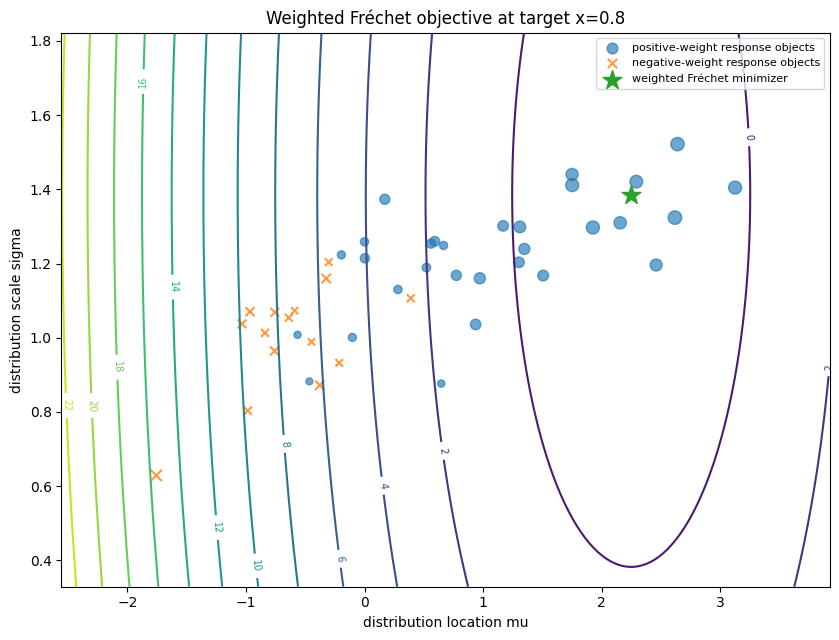

In [8]:

# In the normal location-scale family,
# W2^2{N(mu_i, sigma_i^2), N(mu, sigma^2)}
# = (mu_i - mu)^2 + (sigma_i - sigma)^2.
# This lets us draw the entire weighted Fréchet objective.

target_x = 0.8
factors, weights, fitted_mu, fitted_sigma = fitted_normal_object(target_x)

mu_grid = np.linspace(
    mu_observed.min() - 0.8,
    mu_observed.max() + 0.8,
    180,
)
sigma_grid = np.linspace(
    max(0.1, sigma_observed.min() - 0.3),
    sigma_observed.max() + 0.3,
    160,
)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)

objective = np.zeros_like(MU)
for weight, location, scale in zip(
    weights,
    mu_observed,
    sigma_observed,
):
    objective += weight * (
        (location - MU) ** 2
        + (scale - SIGMA) ** 2
    )

positive = factors >= 0
marker_sizes = 25 + 70 * np.abs(factors) / np.max(np.abs(factors))

plt.figure(figsize=(8.5, 6.5))
contours = plt.contour(MU, SIGMA, objective, levels=15)
plt.clabel(contours, inline=True, fontsize=7)
plt.scatter(
    mu_observed[positive],
    sigma_observed[positive],
    s=marker_sizes[positive],
    alpha=0.65,
    label="positive-weight response objects",
)
plt.scatter(
    mu_observed[~positive],
    sigma_observed[~positive],
    s=marker_sizes[~positive],
    marker="x",
    alpha=0.8,
    label="negative-weight response objects",
)
plt.scatter(
    [fitted_mu],
    [fitted_sigma],
    marker="*",
    s=200,
    label="weighted Fréchet minimizer",
)
plt.xlabel("distribution location mu")
plt.ylabel("distribution scale sigma")
plt.title(f"Weighted Fréchet objective at target x={target_x}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_weighted_frechet_objective.png", dpi=180)
plt.show()


### 4.3 regression curve は object-valued curve

各 `x` に対して一つの scalar を返すのではなく、10%, 50%, 90% quantileを同時に持つ一つの分布を返します。

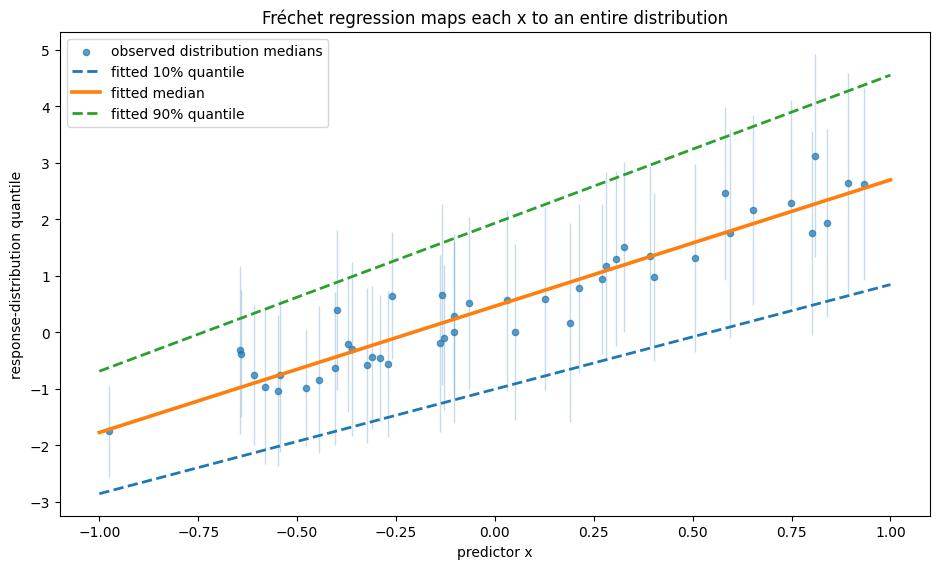

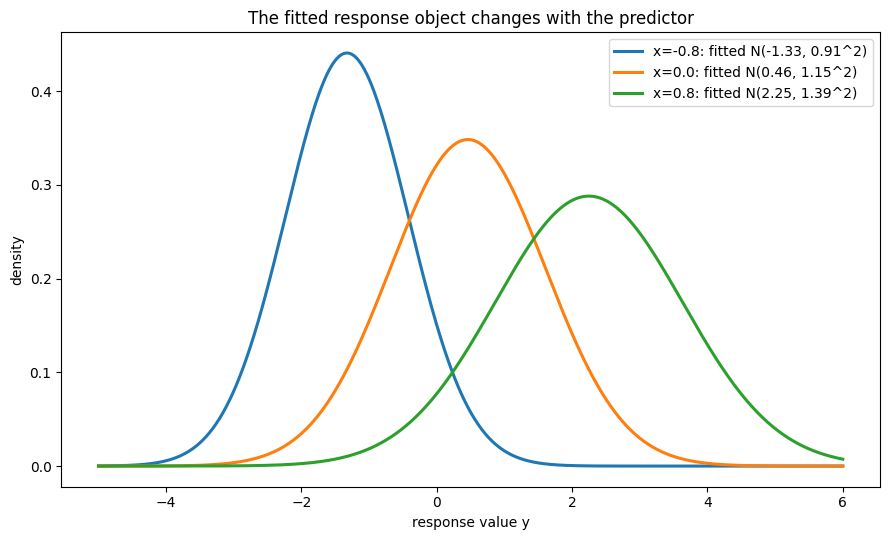

In [9]:

# Represent each observed distribution by its 10%, 50%, and 90% quantiles.
x_grid = np.linspace(-1.0, 1.0, 161)

fitted_mu_curve = np.empty_like(x_grid)
fitted_sigma_curve = np.empty_like(x_grid)
for index, x_value in enumerate(x_grid):
    _, _, fitted_mu_curve[index], fitted_sigma_curve[index] = (
        fitted_normal_object(x_value)
    )

z10 = norm.ppf(0.10)
z90 = norm.ppf(0.90)

observed_q10 = mu_observed + sigma_observed * z10
observed_q50 = mu_observed
observed_q90 = mu_observed + sigma_observed * z90

fitted_q10 = fitted_mu_curve + fitted_sigma_curve * z10
fitted_q50 = fitted_mu_curve
fitted_q90 = fitted_mu_curve + fitted_sigma_curve * z90

plt.figure(figsize=(9.5, 5.8))
plt.vlines(
    X,
    observed_q10,
    observed_q90,
    alpha=0.25,
    linewidth=1,
)
plt.scatter(
    X,
    observed_q50,
    s=20,
    alpha=0.7,
    label="observed distribution medians",
)
plt.plot(
    x_grid,
    fitted_q10,
    linestyle="--",
    linewidth=2,
    label="fitted 10% quantile",
)
plt.plot(
    x_grid,
    fitted_q50,
    linewidth=2.6,
    label="fitted median",
)
plt.plot(
    x_grid,
    fitted_q90,
    linestyle="--",
    linewidth=2,
    label="fitted 90% quantile",
)
plt.xlabel("predictor x")
plt.ylabel("response-distribution quantile")
plt.title("Fréchet regression maps each x to an entire distribution")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_frechet_regression_quantile_band.png", dpi=180)
plt.show()

density_grid = np.linspace(-5.0, 6.0, 900)
plt.figure(figsize=(9, 5.5))
for target in targets:
    _, _, fitted_mu, fitted_sigma = fitted_normal_object(target)
    plt.plot(
        density_grid,
        norm.pdf(density_grid, fitted_mu, fitted_sigma),
        linewidth=2.2,
        label=(
            f"x={target}: fitted "
            f"N({fitted_mu:.2f}, {fitted_sigma:.2f}^2)"
        ),
    )
plt.xlabel("response value y")
plt.ylabel("density")
plt.title("The fitted response object changes with the predictor")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_fitted_distribution_objects.png", dpi=180)
plt.show()


### 4.4 animation

一つ目は `x` の移動に伴う weight の変化、二つ目は fitted distributionそのものの変化です。

In [10]:

# Animation 1: x-dependent global weights.
animation_x = np.linspace(-1.0, 1.0, 61)
all_factors = np.array([
    global_weight_factors(x_value)
    for x_value in animation_x
])

figure = plt.figure(figsize=(8.5, 5.2))
axis = plt.gca()
weight_line, = axis.plot(
    [],
    [],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="weight factor s_i(x)",
)
target_line = axis.axvline(
    0.0,
    linestyle="--",
    linewidth=1.5,
    label="target x",
)
axis.axhline(0.0, linewidth=1)
axis.set_xlim(-1.05, 1.05)
axis.set_ylim(all_factors.min() - 0.2, all_factors.max() + 0.2)
axis.set_xlabel("observed predictor X_i")
axis.set_ylabel("weight factor s_i(x)")
axis.legend(loc="upper center")

def update_weights(x_value):
    factors = global_weight_factors(x_value)
    weight_line.set_data(X[order], factors[order])
    target_line.set_xdata([x_value, x_value])
    axis.set_title(
        f"Global Fréchet-regression weights at target x={x_value:.2f}"
    )
    return weight_line, target_line

weight_animation = FuncAnimation(
    figure,
    update_weights,
    frames=animation_x,
    interval=100,
    blit=False,
)
weight_gif = OUTPUT_DIR / "11_global_weights_animation.gif"
weight_animation.save(weight_gif, writer=PillowWriter(fps=10))
plt.close(figure)

# Animation 2: the distribution-valued fitted object.
figure = plt.figure(figsize=(8.5, 5.2))
axis = plt.gca()
estimated_line, = axis.plot(
    [],
    [],
    linewidth=2.6,
    label="estimated Fréchet regression object",
)
population_line, = axis.plot(
    [],
    [],
    linestyle="--",
    linewidth=2,
    label="population target",
)
median_line = axis.axvline(
    0.0,
    linestyle=":",
    linewidth=1.5,
    label="estimated median",
)
axis.set_xlim(density_grid.min(), density_grid.max())
axis.set_ylim(0.0, 0.5)
axis.set_xlabel("response value y")
axis.set_ylabel("density")
axis.legend(loc="upper right")

def update_distribution(x_value):
    _, _, fitted_mu, fitted_sigma = fitted_normal_object(x_value)

    true_mu = 0.4 + 2.0 * x_value
    true_sigma = 1.15 + 0.30 * x_value

    estimated_line.set_data(
        density_grid,
        norm.pdf(density_grid, fitted_mu, fitted_sigma),
    )
    population_line.set_data(
        density_grid,
        norm.pdf(density_grid, true_mu, true_sigma),
    )
    median_line.set_xdata([fitted_mu, fitted_mu])
    axis.set_title(
        "Fréchet regression at "
        f"x={x_value:.2f}: fitted N({fitted_mu:.2f}, {fitted_sigma:.2f}^2)"
    )
    return estimated_line, population_line, median_line

distribution_animation = FuncAnimation(
    figure,
    update_distribution,
    frames=animation_x,
    interval=100,
    blit=False,
)
distribution_gif = OUTPUT_DIR / "12_fitted_distribution_animation.gif"
distribution_animation.save(
    distribution_gif,
    writer=PillowWriter(fps=10),
)
plt.close(figure)

print(f"Saved: {weight_gif}")
print(f"Saved: {distribution_gif}")


Saved: /mnt/data/frechet_visualization_outputs/11_global_weights_animation.gif
Saved: /mnt/data/frechet_visualization_outputs/12_fitted_distribution_animation.gif


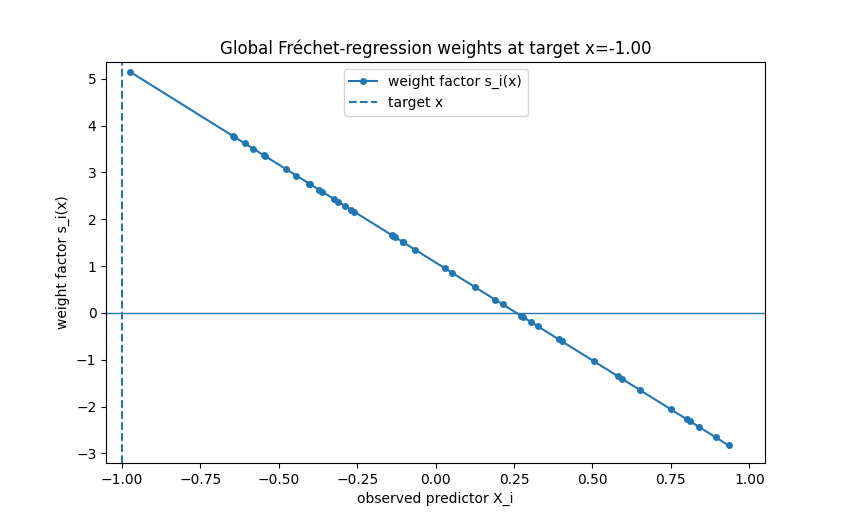

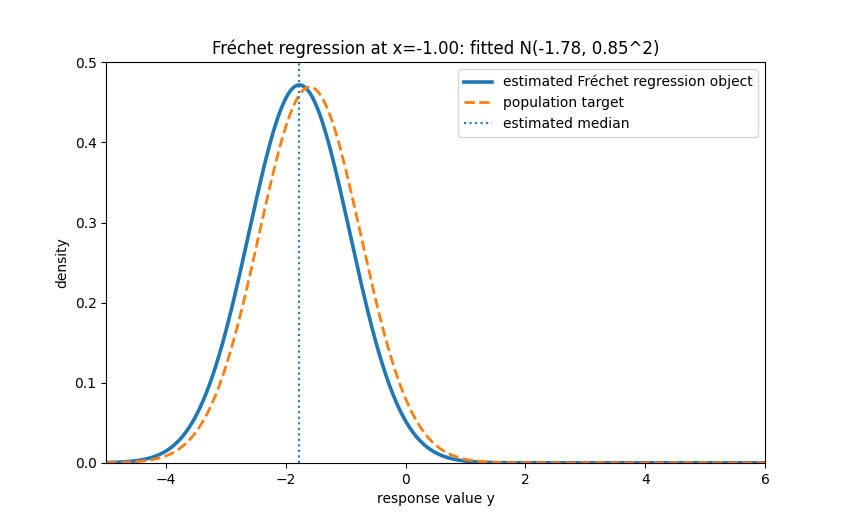

In [11]:
from IPython.display import Image, display
display(Image(filename=str(weight_gif)))
display(Image(filename=str(distribution_gif)))

## 読み方

- Fréchet mean は、対象を無理にベクトル化して平均する操作ではありません。
- 選んだ metric に基づく squared-distance loss の minimizer です。
- Fréchet regression は、その minimizer を predictor ごとの weight で連続的に作り直します。
- metric を変えると Fréchet mean も regression fit も変わります。